# Building a Pipeline for Time Series Data

## Time-series Preprocessing and Exploratory Analysis

## A. Understanding the dataset

To demonstrate a strong understanding of the dataset, you are required to perform exploratory data analysis, showcasing but not limited to the following details:

- What is the time range of the dataset
- What is the frequency/granularity?
- Are there missing values? How did you handle the missing values, and - why was that methodology selected?
- Statistical distribution of numerical columns
- etc
## B. Analytical Questions

You are to come up with at least 5 analytical questions about the dataset you chose and perform data analysis to answer them. Examples of analytical questions include:

- Does the series have an increasing/decreasing trend?
- Do external variables correlate with the target over time?
- Are there lag effects (e.g., sales today related to the previous 7 days)?
- etc
#### NB: In your analytical questions, you must include at least two questions that require using lagged features and moving averages. For each analytical question, you are required to provide at least 1 visualization and a detailed interpretation of the findings

## C. Training a model

- Select a model of your choice (either classical ML models like linear regression or deep neural network architectures like LSTM) to predict the target variable. Make sure to perform hyperparameter tuning and produce an experiment table that shows and compares at least 2 different experiments.



In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.preprocessing import OneHotEncoder


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mikedev/metro-traffic-volume")

print("Path to dataset files:", path)

100%|██████████| 416k/416k [00:00<00:00, 581kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mikedev/metro-traffic-volume/versions/1


## Problem Statement
 - Predict hourly traffic volume using historical traffic and weather data to support smarter transportation planning.

## Justification:

- Traffic congestion affects cities

- Forecasting helps traffic control

- Dataset contains multivariate time-series information

In [ ]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("mikedev/metro-traffic-volume")

csv_file = os.path.join(path, "Metro_Interstate_Traffic_Volume.csv")

df = pd.read_csv(csv_file)

print(df.head())

Using Colab cache for faster access to the 'metro-traffic-volume' dataset.
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


## A. Basic Data Understanding

### 1.a Missing values

In [ ]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [ ]:
df['holiday'] = df.holiday.fillna('No')

In [ ]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


- We can see that holiday has 48143 missing values, this is because it was not a holiday,
  - so we added new class of No (no holiday)

-Since we are not interested

## 1.B Feature Engineering

### 1.B.A Datetime analysis
- Goal
  - We will split the date_time column into
    - Year
    - Month
    - Day
    - Week_day
    - Is weekend
- Questions
  - What is the time range?
  - What is the frequency Hourly?

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [ ]:
df['date_time'].dtype

dtype('<M8[ns]')

In [ ]:
# Create Year, Month, Day, Hour column
df['year'] = df['date_time'].dt.year
df['month'] = df['date_time'].dt.month
df['day'] = df['date_time'].dt.day
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x:1 if x>5 else 0)
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x:1 if x>5 else 0)

In [ ]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0
year,0


In [ ]:
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,year,month,day,day_of_week,is_weekend,hour
0,No,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012,10,2,1,0,9
1,No,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012,10,2,1,0,10
2,No,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012,10,2,1,0,11
3,No,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012,10,2,1,0,12
4,No,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012,10,2,1,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,No,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,2018,9,30,6,1,19
48200,No,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,2018,9,30,6,1,20
48201,No,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,2018,9,30,6,1,21
48202,No,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,2018,9,30,6,1,22


In [ ]:
# df['month_name'] = df['date_time'].dt.month_name()

#### What is the time range?

In [ ]:
year_range = df['year'].unique()
year_range



array([2012, 2013, 2014, 2015, 2016, 2017, 2018], dtype=int32)

#### What is the frequency Hourly?

In [ ]:
df['hour'].mode()

,hour
0,4


### 1.B.B Weather	understanding

In [ ]:
len(df['weather_main'].unique())
len(df['weather_description'].unique())

38

In [ ]:
df['weather_main'].unique()

array(['Clouds', 'Clear', 'Rain', 'Drizzle', 'Mist', 'Haze', 'Fog',
       'Thunderstorm', 'Snow', 'Squall', 'Smoke'], dtype=object)

In [ ]:
result = (
    df.groupby("weather_main")["weather_description"]
      .unique()
      .reset_index()
)

print(result)

    weather_main                                weather_description
0          Clear                       [sky is clear, Sky is Clear]
1         Clouds  [scattered clouds, broken clouds, overcast clo...
2        Drizzle  [light intensity drizzle, drizzle, heavy inten...
3            Fog                                              [fog]
4           Haze                                             [haze]
5           Mist                                             [mist]
6           Rain  [light rain, proximity shower rain, moderate r...
7          Smoke                                            [smoke]
8           Snow  [heavy snow, snow, shower snow, light rain and...
9         Squall                                          [SQUALLS]
10  Thunderstorm  [proximity thunderstorm, thunderstorm with lig...


#### Since we have weather_main wth 11 unique classes, keeping weather_description is redundant and not needed
- We will drop weather_description

### 1.B.C Holiday	understanding

In [ ]:
df['holiday'].unique()

array(['No', 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [ ]:
df.groupby("holiday")["traffic_volume"].mean()

,traffic_volume
holiday,
Christmas Day,827.500000
Columbus Day,519.400000
Independence Day,1076.000000
Labor Day,1013.142857
Martin Luther King Jr Day,612.666667
Memorial Day,1107.600000
New Years Day,1356.000000
No,3262.852170
State Fair,634.800000


#### Since specific holidays affects traffic, so we will keep this column

### 1.B.D Statistical distribution of numerical columns

In [ ]:
numerical_columns = df.select_dtypes(include=['number']).columns
numerical_columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'year',
       'month', 'day', 'day_of_week', 'is_weekend', 'hour'],
      dtype='object')

In [ ]:
df[numerical_columns].describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,year,month,day,day_of_week,is_weekend,hour
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355,2015.512426,6.506037,15.737636,2.984980,0.142561,11.398162
std,13.338232,44.789133,0.008168,39.015750,1986.860670,1.893211,3.400221,8.722938,2.005941,0.349628,6.940238
min,0.000000,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000,2014.000000,4.000000,8.000000,1.000000,0.000000,5.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000,2016.000000,7.000000,16.000000,3.000000,0.000000,11.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000,2017.000000,9.000000,23.000000,5.000000,0.000000,17.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000,2018.000000,12.000000,31.000000,6.000000,1.000000,23.000000


## B. Analytical Questions

In [ ]:
# Sort by datetime to maintain time order
df = df.sort_values('date_time')

# Optional: set as index for rolling calculations
df = df.set_index('date_time')

#### Add Lagging features

In [ ]:
df['lag_1'] = df['traffic_volume'].shift(1)
df['lag_24'] = df['traffic_volume'].shift(24)
df['lag_168'] = df['traffic_volume'].shift(168)

#### Add moving averages

In [ ]:
# 24-hour moving average
df['rolling_mean_24'] = df['traffic_volume'].rolling(24).mean()
df['rolling_mean_168'] = df['traffic_volume'].rolling(168).mean()

#### b.1 Does the series have an increasing/decreasing trend?

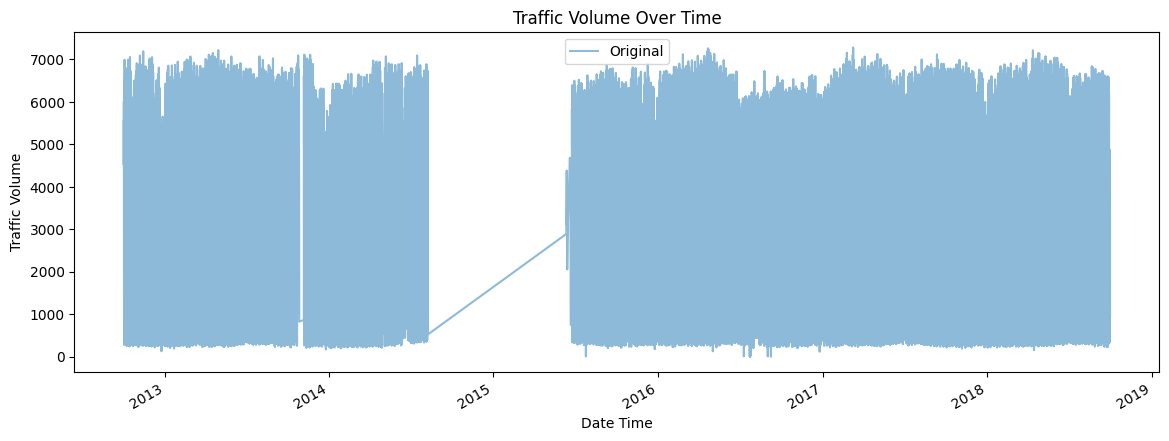

In [ ]:
hourly_avg = df.groupby('day')['traffic_volume'].mean()
plt.figure(figsize=(14,5))
df['traffic_volume'].plot(alpha=0.5, label='Original')
plt.title("Traffic Volume Over Time")
plt.ylabel("Traffic Volume")
plt.xlabel("Date Time")
plt.legend()
plt.show()

#### b.1 Does traffic volume show daily patterns?

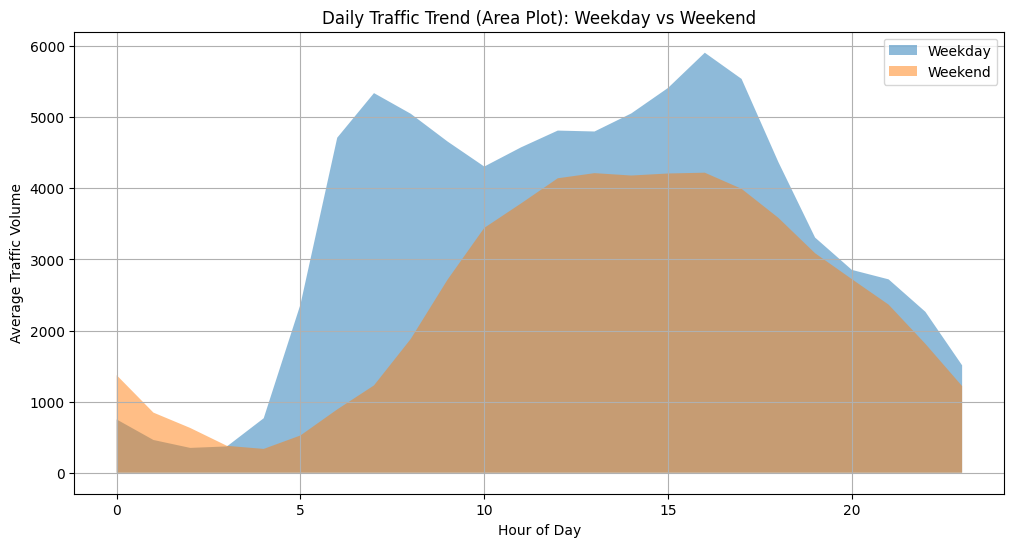

In [ ]:
# Average hourly traffic for weekdays
weekday_hourly = (
    df[df['is_weekend'] == 0]
    .groupby('hour')['traffic_volume']
    .mean()
)

# Average hourly traffic for weekends
weekend_hourly = (
    df[df['is_weekend'] == 1]
    .groupby('hour')['traffic_volume']
    .mean()
)

plt.figure(figsize=(12,6))

plt.fill_between(weekday_hourly.index, weekday_hourly.values,
                 alpha=0.5, label='Weekday')

plt.fill_between(weekend_hourly.index, weekend_hourly.values,
                 alpha=0.5, label='Weekend')

plt.title("Daily Traffic Trend (Area Plot): Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.legend()
plt.grid(True)

plt.show()

##### Conclusion:
- we can see that on weekday, traffic increases at 5 and reaches first peak at 8 as people are commutting to work, which is the lowest in weekend as people are still resting
- Then the highest peak happens at 4PM for weekdays as people are getting off from work
- For weekends, the peak is reached at 12PM to 4PM, which is lower compared to weekdays

#### b.2 Do external variables correlate with the target over time?

In [ ]:
numerical_columns = df.select_dtypes(include=['number']).columns
numerical_columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'year',
       'month', 'day', 'day_of_week', 'is_weekend', 'hour', 'lag_1', 'lag_24',
       'lag_168', 'rolling_mean_24', 'rolling_mean_168'],
      dtype='object')

traffic_volume    1.000000
temp              0.130299
clouds_all        0.067054
rain_1h           0.004714
snow_1h           0.000733
Name: traffic_volume, dtype: float64


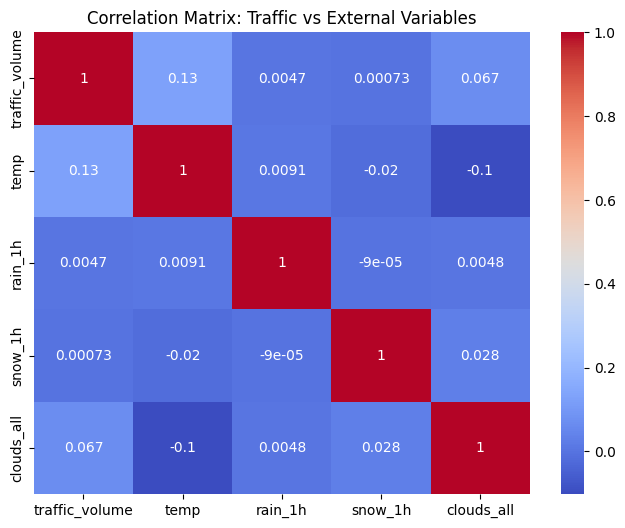

In [ ]:
corr_matrix = df[['traffic_volume',
                  'temp',
                  'rain_1h',
                  'snow_1h',
                  'clouds_all']].corr()

print(corr_matrix['traffic_volume'].sort_values(ascending=False))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Traffic vs External Variables')
plt.show()

#### Conclusion:
- We can see temperature has the highest correlation with traffic volume, this is because there is a lot of movements when there is a sun(probably in summer)
- we can also see that rain_1h and snow_1h have the lowest correlation with traffic volume as there is less movement when it is raining and snowing compared to when there is the sun

#### b.3 Is traffic lower on weekends compared to weekdays?

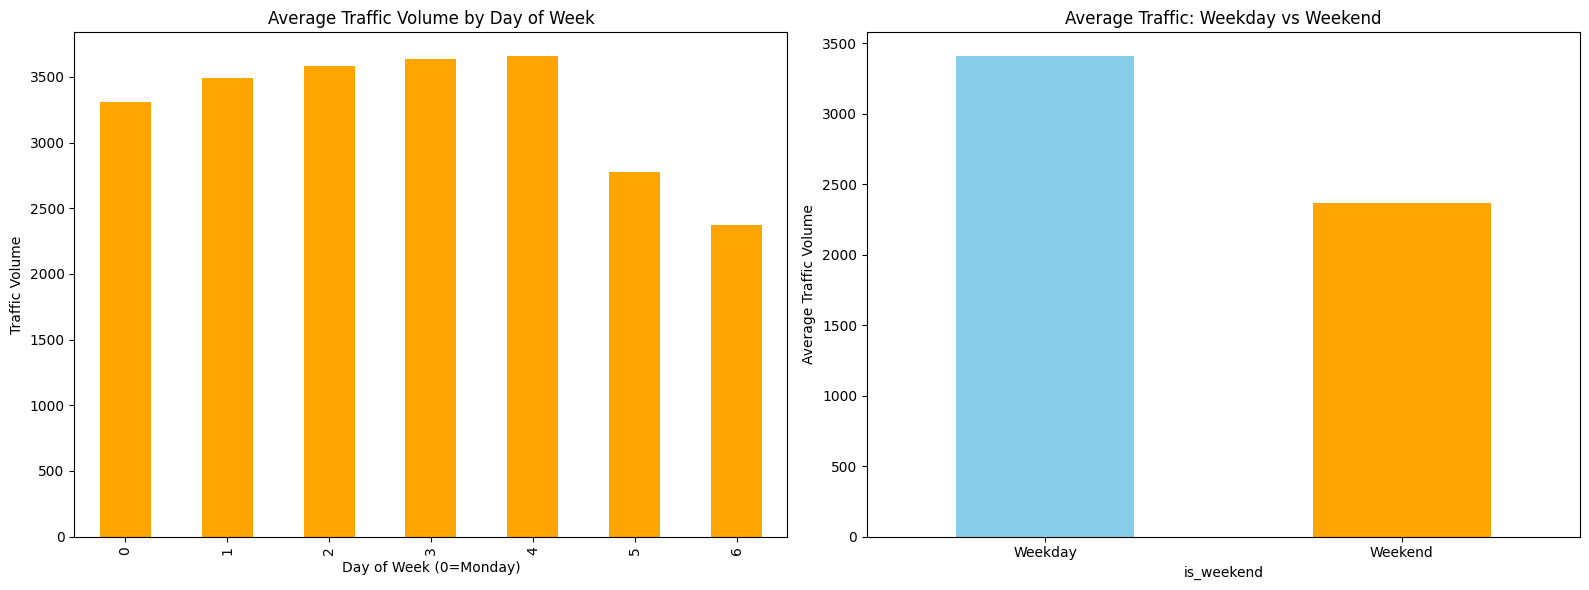

In [ ]:
dow_avg = df.groupby('day_of_week')['traffic_volume'].mean()
weekday_avg = df.groupby('is_weekend')['traffic_volume'].mean()

plt.figure(figsize=(16,6))

# Subplot 1: Day of Week
plt.subplot(1,2,1)  # 1 row, 2 columns, first plot
dow_avg.plot(kind='bar', color='orange')
plt.title("Average Traffic Volume by Day of Week")
plt.ylabel("Traffic Volume")
plt.xlabel("Day of Week (0=Monday)")

# Subplot 2: Weekday vs Weekend
plt.subplot(1,2,2)  # 1 row, 2 columns, second plot
weekday_avg.plot(kind='bar', color=['skyblue','orange'])
plt.title('Average Traffic: Weekday vs Weekend')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Traffic Volume')

plt.tight_layout()
plt.show()

#### Conclusion:
- We can see that traffic starts to increase on Monday and reaches it's peak on Thursday and Friday
- We can also see that the traffic is lower in weekends compared to weekday
- Peak traffic is Friday and lowest on Sunday


#### b.4 Lag Question #1 : Is current traffic correlated with previous hour traffic?

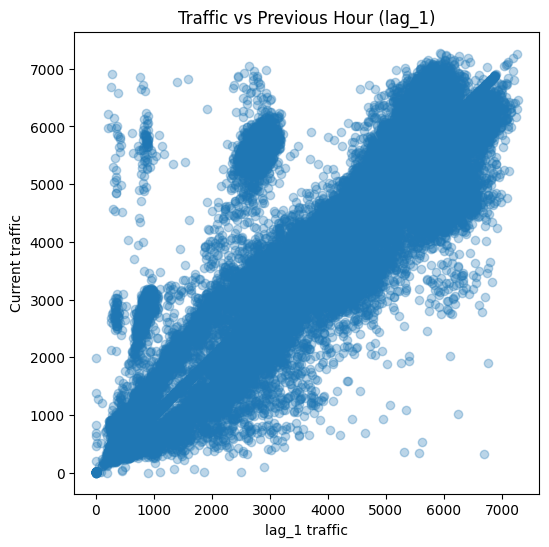

Correlation with lag_1: 0.9127024656313536


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df['lag_1'], df['traffic_volume'], alpha=0.3)
plt.title("Traffic vs Previous Hour (lag_1)")
plt.xlabel("lag_1 traffic")
plt.ylabel("Current traffic")
plt.show()

# Correlation
corr_lag1 = df[['traffic_volume','lag_1']].corr().iloc[0,1]
print("Correlation with lag_1:", corr_lag1)

#### b.5 Lag Question #2 : Is traffic volume at a given hour influenced by traffic 24 hours earlier?

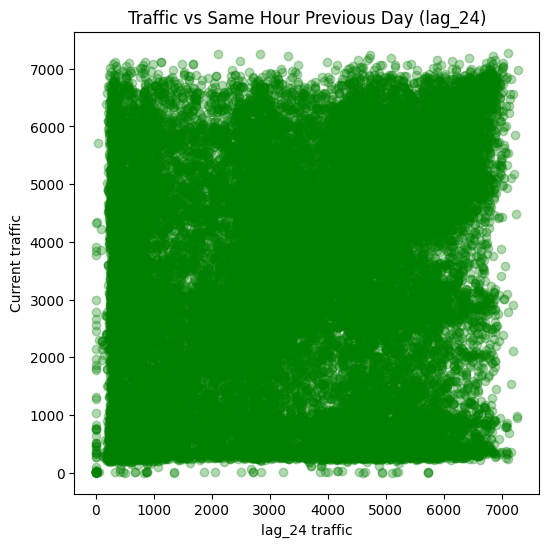

Correlation with lag_24: 0.3695149209101615


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df['lag_24'], df['traffic_volume'], alpha=0.3, color='green')
plt.title("Traffic vs Same Hour Previous Day (lag_24)")
plt.xlabel("lag_24 traffic")
plt.ylabel("Current traffic")
plt.show()

# Correlation
corr_lag24 = df[['traffic_volume','lag_24']].corr().iloc[0,1]
print("Correlation with lag_24:", corr_lag24)

#### Moving Average Question: Does the 24-hour moving average reveal clearer trends compared to raw data?

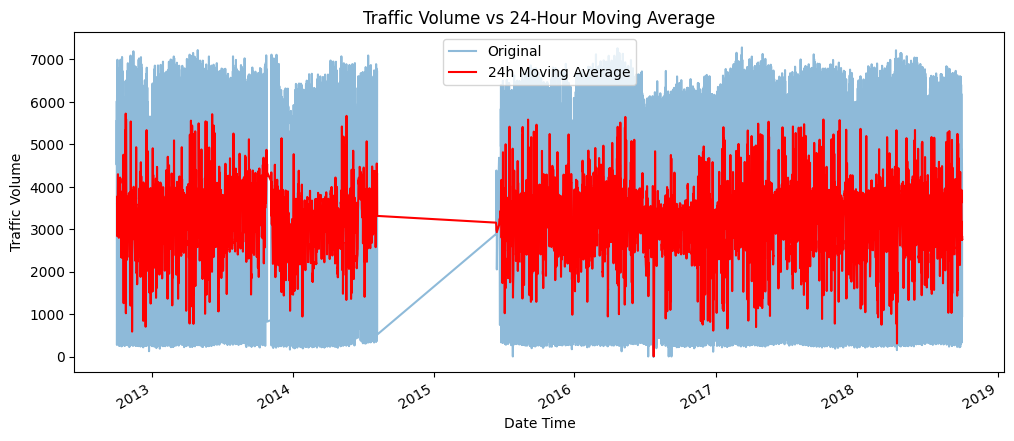

In [ ]:
plt.figure(figsize=(12,5))
df['traffic_volume'].plot(alpha=0.5, label='Original')
df['rolling_mean_24'].plot(color='red', label='24h Moving Average')
plt.title("Traffic Volume vs 24-Hour Moving Average")
plt.ylabel("Traffic Volume")
plt.xlabel("Date Time")
plt.legend()
plt.show()

In [ ]:
data = df[df['year'] == 2015]
data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,day_of_week,is_weekend,hour,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
date_time,,,,,,,,,,,,,,,,,,,
2015-06-11 20:00:00,No,287.586,0.0,0.0,92,Rain,light rain,2886,2015,6,11,3,0,20,516.0,6688.0,6151.0,3153.208333,3748.880952
2015-06-12 18:00:00,No,297.543,0.0,0.0,0,Clear,Sky is Clear,4380,2015,6,12,4,0,18,2886.0,6254.0,6537.0,3075.125000,3736.041667
2015-06-12 20:00:00,No,292.061,0.0,0.0,8,Clear,sky is clear,3095,2015,6,12,4,0,20,4380.0,4970.0,6317.0,2997.000000,3716.863095
2015-06-12 21:00:00,No,292.061,0.0,0.0,8,Clear,sky is clear,3299,2015,6,12,4,0,21,3095.0,3783.0,4986.0,2976.833333,3706.821429
2015-06-13 21:00:00,No,294.840,0.0,0.0,76,Clouds,broken clouds,3040,2015,6,13,5,0,21,3299.0,3255.0,3773.0,2967.875000,3702.458333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 15:00:00,No,264.830,0.0,0.0,90,Snow,light snow,5747,2015,12,31,3,0,15,5747.0,2564.0,778.0,3451.833333,2427.845238
2015-12-31 16:00:00,No,264.890,0.0,0.0,90,Snow,light snow,5467,2015,12,31,3,0,16,5747.0,2412.0,374.0,3579.125000,2458.160714
2015-12-31 19:00:00,No,265.320,0.0,0.0,90,Snow,light snow,3576,2015,12,31,3,0,19,5467.0,1479.0,454.0,3666.500000,2476.744048


## PART C: Training a model

### A: Enocde features and Split data into training and testing

In [ ]:
df_cleaned = df.drop('weather_description', axis=1)
df_cleaned

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,year,month,day,day_of_week,is_weekend,hour,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
date_time,,,,,,,,,,,,,,,,,,
2012-10-02 09:00:00,No,288.28,0.0,0.0,40,Clouds,5545,2012,10,2,1,0,9,NaN,NaN,NaN,NaN,NaN
2012-10-02 10:00:00,No,289.36,0.0,0.0,75,Clouds,4516,2012,10,2,1,0,10,5545.0,NaN,NaN,NaN,NaN
2012-10-02 11:00:00,No,289.58,0.0,0.0,90,Clouds,4767,2012,10,2,1,0,11,4516.0,NaN,NaN,NaN,NaN
2012-10-02 12:00:00,No,290.13,0.0,0.0,90,Clouds,5026,2012,10,2,1,0,12,4767.0,NaN,NaN,NaN,NaN
2012-10-02 13:00:00,No,291.14,0.0,0.0,75,Clouds,4918,2012,10,2,1,0,13,5026.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-30 19:00:00,No,283.45,0.0,0.0,75,Clouds,3543,2018,9,30,6,1,19,3947.0,2950.0,4351.0,2829.333333,3418.922619
2018-09-30 20:00:00,No,282.76,0.0,0.0,90,Clouds,2781,2018,9,30,6,1,20,3543.0,2607.0,4468.0,2836.583333,3408.880952
2018-09-30 21:00:00,No,282.73,0.0,0.0,90,Thunderstorm,2159,2018,9,30,6,1,21,2781.0,3856.0,4531.0,2765.875000,3394.761905


In [ ]:
df.isnull().sum()

,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
traffic_volume,0
year,0
month,0


In [ ]:
df_cleaned1 = df_cleaned.dropna()

#### Encode categorical
- We will encode holiday, weather_main and day_of_week

In [ ]:
df_encoded = pd.get_dummies(df_cleaned1, columns=['holiday', 'weather_main', 'day_of_week'], drop_first=True)
df_encoded

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,year,month,day,is_weekend,hour,...,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
date_time,,,,,,,,,,,,,,,,,,,,,
2012-10-09 19:00:00,288.86,0.0,0.0,75,3418,2012,10,9,0,19,...,False,False,False,False,True,False,False,False,False,False
2012-10-09 20:00:00,287.36,0.0,0.0,90,2775,2012,10,9,0,20,...,False,False,False,False,True,False,False,False,False,False
2012-10-09 21:00:00,285.11,0.0,0.0,90,2306,2012,10,9,0,21,...,False,False,False,False,True,False,False,False,False,False
2012-10-09 22:00:00,283.46,0.0,0.0,90,1846,2012,10,9,0,22,...,False,False,False,False,True,False,False,False,False,False
2012-10-09 23:00:00,282.45,0.0,0.0,90,947,2012,10,9,0,23,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-30 19:00:00,283.45,0.0,0.0,75,3543,2018,9,30,1,19,...,False,False,False,False,False,False,False,False,False,True
2018-09-30 20:00:00,282.76,0.0,0.0,90,2781,2018,9,30,1,20,...,False,False,False,False,False,False,False,False,False,True
2018-09-30 21:00:00,282.73,0.0,0.0,90,2159,2018,9,30,1,21,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
len(df_encoded.columns)

42

#### since regression models might treat the year, month, day and hour as if they are numeric values and compare them numerically, we have decided to drop them for now

In [ ]:
df_encoded1 = df_encoded.drop(columns=['year', 'month', 'day', 'hour'])
len(df_encoded1.columns)

38

In [ ]:
# Train: 2012–2016
train = df_encoded[df_encoded['year']<= 2016]

# Test: 2017–2018
test = df_encoded[df_encoded['year'] >= 2017]

In [ ]:
y_train = train['traffic_volume']
X_train = train.drop('traffic_volume', axis=1)

y_test = test['traffic_volume']
X_test = test.drop('traffic_volume', axis=1)

In [ ]:
X_train.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'year', 'month', 'day',
       'is_weekend', 'hour', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
       'rolling_mean_168', 'holiday_Columbus Day', 'holiday_Independence Day',
       'holiday_Labor Day', 'holiday_Martin Luther King Jr Day',
       'holiday_Memorial Day', 'holiday_New Years Day', 'holiday_No',
       'holiday_State Fair', 'holiday_Thanksgiving Day',
       'holiday_Veterans Day', 'holiday_Washingtons Birthday',
       'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog',
       'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain',
       'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall',
       'weather_main_Thunderstorm', 'day_of_week_1', 'day_of_week_2',
       'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6'],
      dtype='object')

## B. Model Training

### Linear Regression
- Experiment1

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 692.5728235382011
Linear Regression R2: 0.8777825393754455


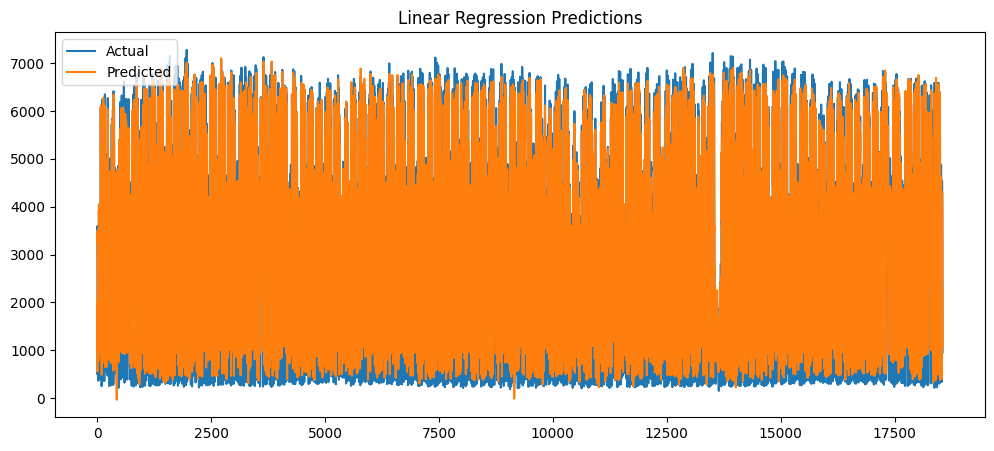

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Predicted')
plt.legend()
plt.title("Linear Regression Predictions")
plt.show()

#### RIDGE
- Experiment2

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # alpha is a hyperparameter
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [ ]:
rmse_rdg = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_rdg = r2_score(y_test, y_pred_ridge)

print("Linear Regression RMSE:", rmse_rdg)
print("Linear Regression R2:", r2_rdg)

Linear Regression RMSE: 692.5410661177524
Linear Regression R2: 0.8777937475030646


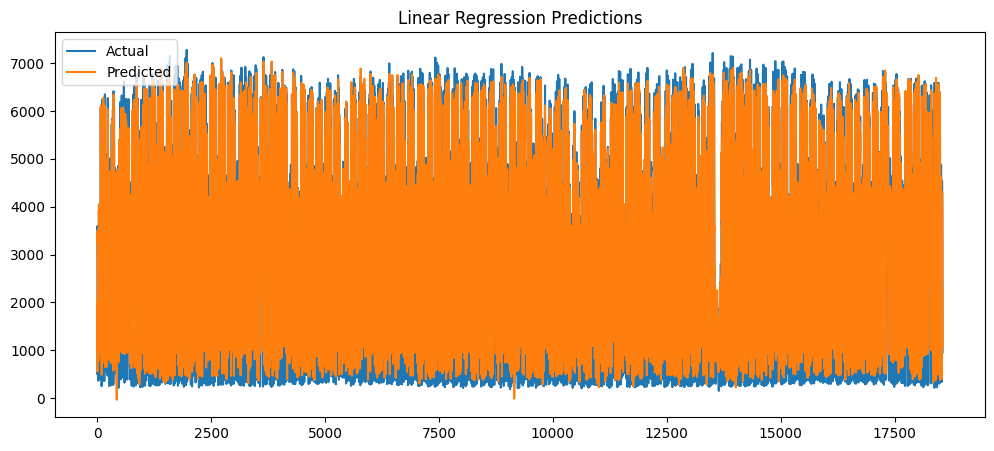

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Predicted')
plt.legend()
plt.title("Linear Regression Predictions")
plt.show()

#### Let's add similarity to capture hour similarity

### LTSM

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit only on training data
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [ ]:
import numpy as np

def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
time_steps = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

In [ ]:
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(time_steps, X_train.shape[1])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0463 - val_loss: 0.0115
Epoch 2/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0150 - val_loss: 0.0104
Epoch 3/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0114 - val_loss: 0.0098
Epoch 4/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0104 - val_loss: 0.0091
Epoch 5/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0094 - val_loss: 0.0072
Epoch 6/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0084 - val_loss: 0.0069
Epoch 7/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0080 - val_loss: 0.0053
Epoch 8/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0072 - val_loss: 0.0058
Epoch 9/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0072 - val_loss: 0.0057
Epoch 10/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0069 - val_loss: 0.0057
Epoch 11/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 12/15
921/921 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/s

In [ ]:
y_pred_scaled = model.predict(X_test_seq)

# Reverse scaling
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2_lstm = r2_score(y_test_actual, y_pred)

print("LSTM RMSE:", rmse_lstm)
print("LSTM R2:", r2_lstm)

LSTM RMSE: 496.0233563164696
LSTM R2: 0.9373368514090653


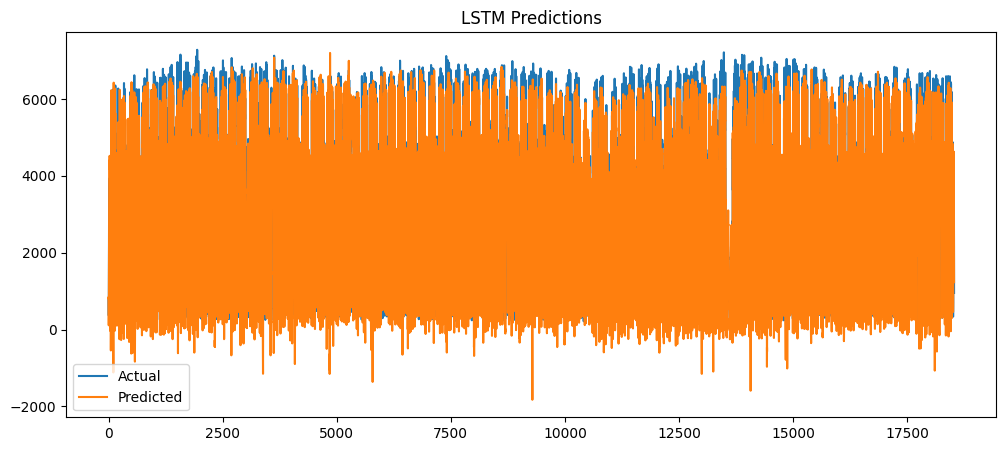

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("LSTM Predictions")
plt.show()

#### LSTM 2

In [ ]:
time_steps_2 = 48  # 48 hours (2 days)

X_train_seq2, y_train_seq2 = create_sequences(X_train_scaled, y_train_scaled, time_steps_2)
X_test_seq2, y_test_seq2 = create_sequences(X_test_scaled, y_test_scaled, time_steps_2)

print("X_train_seq2 shape:", X_train_seq2.shape)
print("y_train_seq2 shape:", y_train_seq2.shape)

X_train_seq2 shape: (29434, 48, 41)
y_train_seq2 shape: (29434, 1)


In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Dropout
model2 = Sequential()
model2.add(LSTM(128, activation='relu', input_shape=(time_steps_2, X_train.shape[1])))
model2.add(Dropout(0.2))
model2.add(Dense(1))

model2.compile(optimizer='adam', loss='mse')
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        87,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,169 (340.50 KB)

 Trainable params: 87,169 (340.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(
    X_train_seq2,
    y_train_seq2,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq2, y_test_seq2),
    verbose=1
)

Epoch 1/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0473 - val_loss: 0.0156
Epoch 2/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0173 - val_loss: 0.0091
Epoch 3/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0146 - val_loss: 0.0083
Epoch 4/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0137 - val_loss: 0.0084
Epoch 5/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0119 - val_loss: 0.0062
Epoch 6/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0123 - val_loss: 0.0064
Epoch 7/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0104 - val_loss: 0.0063
Epoch 8/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0098 - val_loss: 0.0058
Epoch 9/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0094 - val_loss: 0.0055
Epoch 10/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0086 - val_loss: 0.0079
Epoch 11/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0082 - val_loss: 0.0062
Epoch 12/20
920/920 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/

In [ ]:
y_pred_scaled2 = model2.predict(X_test_seq2)

# Convert back to original traffic volume
y_pred2 = scaler_y.inverse_transform(y_pred_scaled2)
y_test_actual2 = scaler_y.inverse_transform(y_test_seq2)

579/579 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lstm2 = np.sqrt(mean_squared_error(y_test_actual2, y_pred2))
r2_lstm2 = r2_score(y_test_actual2, y_pred2)

print("LSTM 2 RMSE:", rmse_lstm2)
print("LSTM 2 R2:", r2_lstm2)

LSTM 2 RMSE: 551.0596709520503
LSTM 2 R2: 0.9227009668623266


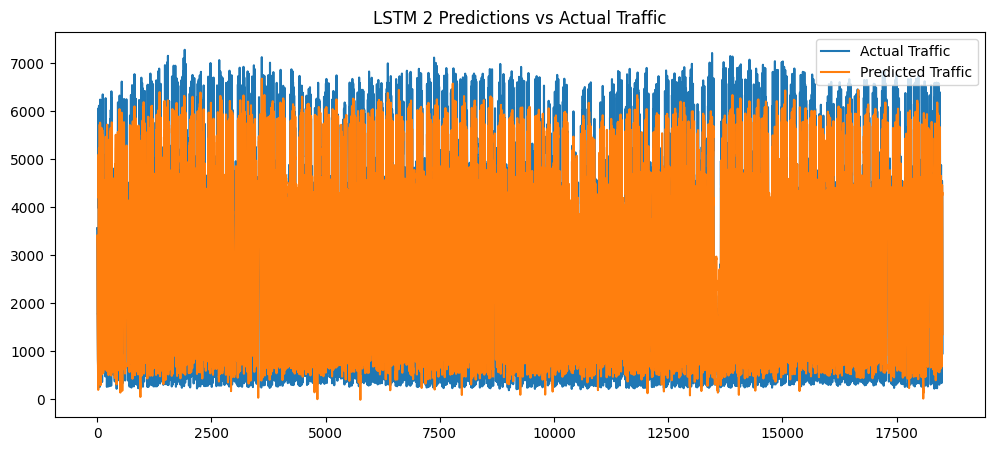

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual2, label='Actual Traffic')
plt.plot(y_pred2, label='Predicted Traffic')
plt.legend()
plt.title("LSTM 2 Predictions vs Actual Traffic")
plt.show()

## Summary
### Save models
- We are going to save:
  - Linear Regression model
  - LTSM model
  - Scalers

In [ ]:
import joblib

# Save Linear Regression model
joblib.dump(lr, 'linear_regression_model.pkl')

# Save MinMaxScalers for X and y
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

In [ ]:
# Save entire LSTM model including architecture and weights
model.save('LTSM_model.h5')

In [ ]:
# Sva the column names
input_columns = df_encoded1.columns.tolist()
len(input_columns)
joblib.dump(input_columns, 'input_columns.pkl')


['input_columns.pkl']

In [ ]:
# # Load model
# lr_loaded = joblib.load('linear_regression_model.pkl')

# # Load scalers
# scaler_X_loaded = joblib.load('scaler_X.pkl')
# scaler_y_loaded = joblib.load('scaler_y.pkl')

# from tensorflow.keras.models import load_model

# lstm_loaded = load_model('lstm_model1.h5')

### Pipeline steps

- Convert holiday missing values → "No"

- Convert date_time to datetime

- Create year, month, day, hour, day_of_week, is_weekend

- Add lag features (shift)

- Add rolling averages

- Drop unnecessary columns (weather_description)

- Drop NA rows from lag/rolling

- Encode categorical features (holiday, weather_main, day_of_week)

- Drop year/month/day/hour columns

- Scale features if using LSTM